<a href="https://colab.research.google.com/github/CS171-Semester-Project/traffic-sign-detection/blob/main/traffic_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

In [ ]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

###**DATA PREPARATION**

In [ ]:
# Download the dataset
!kaggle datasets download -d pkdarabi/cardetection

# Unzip the downloaded dataset
!unzip -q cardetection.zip -d cardetection_dataset

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:05<00:00, 17.8MB/s]



In [ ]:
for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/train"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/test"):
    print(f"Test data path: {dirpath}")
    print(f"Test data directories length: {len(dirnames)}")
    print(f"Test data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/valid"):
    print(f"Validation data path: {dirpath}")
    print(f"Validation data directories length: {len(dirnames)}")
    print(f"Validation data filenames length: {len(filenames)}")

Train data path: cardetection_dataset/car/train
Train data directories length: 2
Train data filenames length: 0
Train data path: cardetection_dataset/car/train/images
Train data directories length: 0
Train data filenames length: 3530
Train data path: cardetection_dataset/car/train/labels
Train data directories length: 0
Train data filenames length: 3530

Test data path: cardetection_dataset/car/test
Test data directories length: 2
Test data filenames length: 0
Test data path: cardetection_dataset/car/test/images
Test data directories length: 0
Test data filenames length: 638
Test data path: cardetection_dataset/car/test/labels
Test data directories length: 0
Test data filenames length: 638

Validation data path: cardetection_dataset/car/valid
Validation data directories length: 2
Validation data filenames length: 0
Validation data path: cardetection_dataset/car/valid/images
Validation data directories length: 0
Validation data filenames length: 801
Validation data path: cardetection_da

In [ ]:
import yaml

yaml_path = "cardetection_dataset/car/data.yaml"

with open(yaml_path, "r") as f:
    data_info = yaml.safe_load(f)

In [ ]:
# Getting all the class or label names
class_names = data_info.get('names', [])
print(f"Total Number of Classes: {len(class_names)}\n")

print("Class Names:")
for i+1, name in enumerate(class_names):
    print(f"{i}: {name}")

Total Number of Classes: 15

Class Names:
0: Green Light
1: Red Light
2: Speed Limit 10
3: Speed Limit 100
4: Speed Limit 110
5: Speed Limit 120
6: Speed Limit 20
7: Speed Limit 30
8: Speed Limit 40
9: Speed Limit 50
10: Speed Limit 60
11: Speed Limit 70
12: Speed Limit 80
13: Speed Limit 90
14: Stop


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import glob

In [ ]:
# Get all train images
view_train_img = glob.glob("cardetection_dataset/car/train/images/*.jpg")
if not view_train_img:
    view_train_img = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

In [ ]:
print(f"Train images length: {len(view_train_img)}")

Train images length: 3530


In [ ]:
# Function to get labels for each image
def get_labels(img_path):
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    found_classes = set()
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = int(parts[0])
                    if "data_info" in globals() and "names" in data_info:
                        class_name = data_info["names"][class_id]
                    else:
                        class_name = f"Class {class_id}"
                    found_classes.add(class_name)
    if found_classes:
        return f"\nLabel: {", ".join(list(found_classes))}"

    return "\nLabel: None"

Image shape: (416, 416, 3)


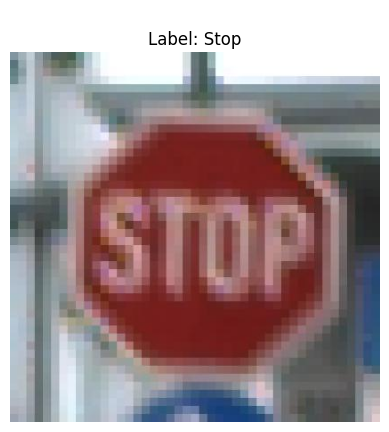

In [ ]:
# Visualize one train image with a label
if view_train_img:
    train_img_path = random.choice(view_train_img)
    train_img = mpimg.imread(train_img_path)
    plt.imshow(train_img)
    title = get_labels(train_img_path)
    plt.title(title)
    plt.axis("off")
    print(f"Image shape: {train_img.shape}")
    plt.show()
else:
    print("No train images found")

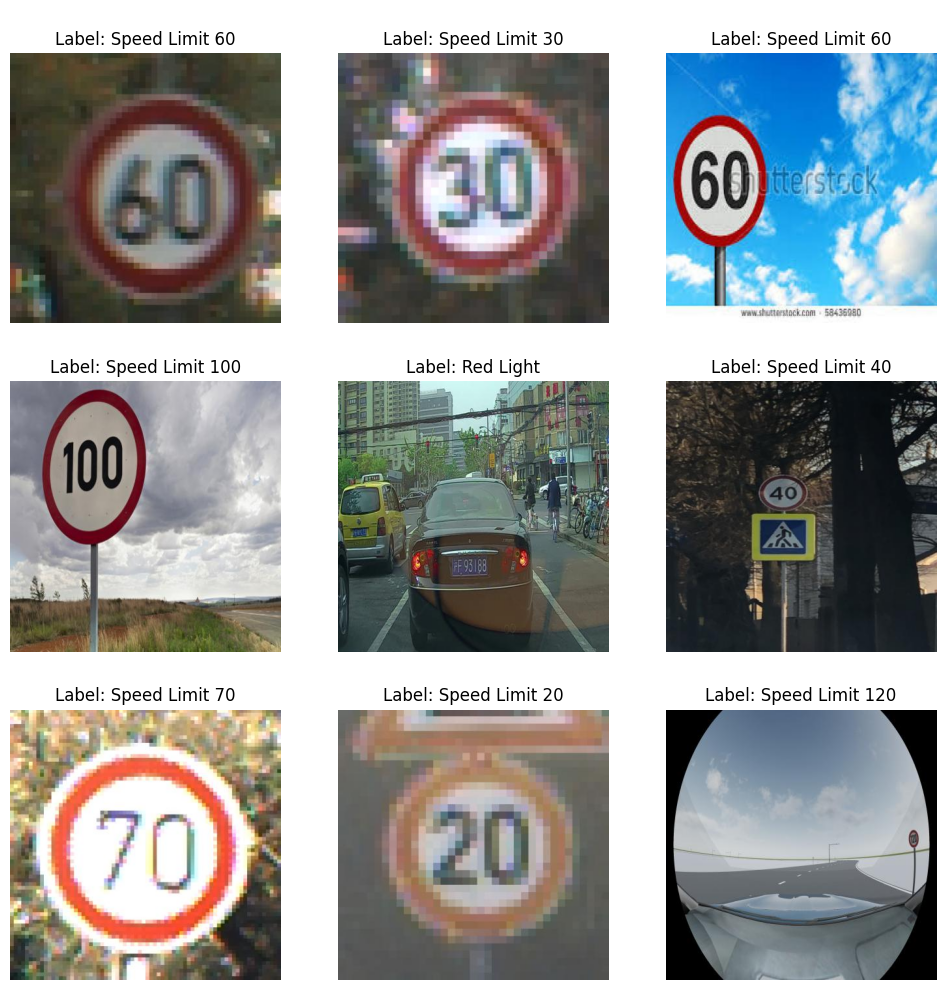

In [ ]:
# Visualize multiple train images with labels
samples = random.sample(view_train_img, min(9, len(view_train_img)))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    ax =axes[i]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

    title = get_labels(img_path)
    ax.set_title(title)

plt.tight_layout()
plt.show()

###**DATA PREPROCESSING**

In [ ]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class TrafficSignDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, B=2, C=15, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.images = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_file = self.images[index]
        img_path = os.path.join(self.img_dir, img_file)

        # Determine corresponding label file path
        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)

        # Parse bounding boxes
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if data:
                        class_label = int(data[0])
                        x = float(data[1])
                        y = float(data[2])
                        width = float(data[3])
                        height = float(data[4])
                        boxes.append([class_label, x, y, width, height])

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Apply transformations.
        # Note: Since YOLO coordinates are normalized, standard resizing
        # preserves spatial accuracy without altering the bounding box values.
        if self.transform:
            image = self.transform(image)

        # Initialize target tensor
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))

        for box in boxes:
            class_label, x, y, width, height = box

            # Grid Assignment
            i, j = int(self.S * y), int(self.S * x)

            # Coordinate Conversion
            x_cell, y_cell = self.S * x - j, self.S * y - i
            width_cell, height_cell = width * self.S, height * self.S

            # Tensor Population
            if label_matrix[i, j, self.C] == 0:
                # Set objectness score to 1
                label_matrix[i, j, self.C] = 1

                # Assign relative box coordinates
                box_coordinates = torch.tensor(
                    [x_cell, y_cell, width_cell, height_cell]
                )
                label_matrix[i, j, self.C + 1: self.C + 5] = box_coordinates

                # Apply one-hot encoding for the class
                label_matrix[i, j, class_label] = 1

        return image, label_matrix


# Define execution parameters
GRID_SIZE = 7
BBOXES = 2
CLASSES = 15
BATCH_SIZE = 16
NUM_WORKERS = 2

# Define transformations
transform_pipeline = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
])

# Define directory paths
train_img_dir = 'cardetection_dataset/car/train/images'
train_label_dir = 'cardetection_dataset/car/train/labels'
val_img_dir = 'cardetection_dataset/car/valid/images'
val_label_dir = 'cardetection_dataset/car/valid/labels'
test_img_dir = 'cardetection_dataset/car/test/images'
test_label_dir = 'cardetection_dataset/car/test/labels'

# Instantiate datasets
train_dataset = TrafficSignDataset(
    img_dir=train_img_dir,
    label_dir=train_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

val_dataset = TrafficSignDataset(
    img_dir=val_img_dir,
    label_dir=val_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

test_dataset = TrafficSignDataset(
    img_dir=test_img_dir,
    label_dir=test_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

# Initialize DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

###**MODEL BUILDING**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class TrafficSignDetector(nn.Module):
    def __init__(self, class_names, num_boxes=1):
        super(TrafficSignDetector, self).__init__()
        self.grid_size = 7
        self.output_depth = (num_boxes * 5) + num_classes

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.AdaptiveAvgPool2d((self.grid_size, self.grid_size))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * self.grid_size * self.grid_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, self.output_depth * self.grid_size * self.grid_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)

        x = x.view(-1, self.output_depth, self.grid_size, self.grid_size)
        return x

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
model = TrafficSignDetector(len(class_names))

In [ ]:
!pip install torchinfo

In [ ]:
# Get model summary
import torchinfo

torchinfo.summary(model=model)

Layer (type:depth-idx)                   Param #
TrafficSignDetector                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       448
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       4,640
│    └─ReLU: 2-4                         --
│    └─Conv2d: 2-5                       18,496
│    └─ReLU: 2-6                         --
├─Sequential: 1-2                        --
│    └─Flatten: 2-7                      --
│    └─Linear: 2-8                       983,055
Total params: 1,006,639
Trainable params: 1,006,639
Non-trainable params: 0

###**MODEL TRAINING**

In [ ]:
from torchvision.ops import box_iou, box_convert

In [ ]:
def custom_loss(predictions, targets):
    object_exists = targets[:, 4:5, :, :] == 1
    background = targets[:, 4:5, :, :] == 0

    mse_loss = nn.MSELoss(reduction='sum')
    bce_loss = nn.BCEWithLogitsLoss(reduction='sum')

    # Bounding box error
    pred_boxes = predictions[:, :4, :, :].permute(0, 2, 3, 1)
    target_boxes = targets[:, :4, :, :].permute(0, 2, 3, 1)

    obj_mask = object_exists.squeeze(1)

    if obj_mask.any():
        p_boxes = pred_boxes[obj_mask]
        t_boxes = target_boxes[obj_mask]

        p_boxes_xyxy = box_convert(p_boxes, in_fmt='cxcywh', out_fmt='xyxy')
        t_boxes_xyxy = box_convert(t_boxes, in_fmt='cxcywh', out_fmt='xyxy')

        ious = box_iou(p_boxes_xyxy, t_boxes_xyxy).diag()
        box_loss = (1 - ious).sum()
    else:
        box_loss = torch.tensor(0.0, device=predictions.device)

    # Confidence error
    pred_conf = predictions[:, 4:5, :, :]
    target_conf = targets[:, 4:5, :, :]

    conf_loss_real_object = mse_loss(pred_conf[object_exists], target_conf[object_exists])
    conf_loss_imagined = mse_loss(pred_conf[background], target_conf[background])

    conf_loss = conf_loss_real_object + (0.5 * conf_loss_imagined)

    # Classification error
    pred_classes = predictions[:, 5:, :, :]
    target_classes = targets[:, 5:, :, :]
    class_loss = bce_loss(pred_classes[object_exists.expand_as(pred_classes)],
                          target_classes[object_exists.expand_as(target_classes)])

    total_loss = box_loss + conf_loss + class_loss

    return total_loss / predictions.size(0)

optimizer = optim.Adam(params=model.parameters(), lr=0.001)

In [ ]:
epochs = 30

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        predictions = model(images)
        loss = custom_loss(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    loss_values.append(epoch_loss)

    model.eval()
    with torch.inference_mode():
        test_loss = 0.0
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)

            test_pred = model(test_images)
            test_loss = loss_fn(test_pred, test_labels)

    epoch_count.append(epoch)
    loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())

    print(f"Epoch: {epoch+1} | Loss: {loss.item()} | Test Loss: {test_loss.item()}")

###**MODEL TESTING**

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
# Gather predicted and actual values

def get_predictions(model, dataloader, device, confidence_threshold=0.2):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            batch_size = logits.shape[0]

            for batch in range(batch_size):
                pred = logits[b]

                pred_boxes_cxcywh = pred[:4, :, :].reshape(4, -1).permute(1, 0)
                pred_scores = torch.sigmoid(pred[4, :, :].reshape(-1))
                pred_classes = torch.argmax(pred[5:, :, :], dim=0).reshape(-1)

                pred_boxes_xyxy = box_convert(pred_boxes_cxcywh, in_fmt='cxcywh', out_fmt='xyxy')

                mask = pred_scores > confidence_threshold

                all_predictions.append({
                    'boxes': pred_boxes_xyxy[mask],
                    'scores': pred_scores[mask],
                    'labels': pred_classes[mask]
                })

                target = targets[batch]

                target_boxes_cxcywh = target[:4, :, :].reshape(4, -1).permute(1, 0)
                target_confidence = target[4, :, :].reshape(-1)
                target_classes = torch.argmax(target[5:, :, :], dim=0).reshape(-1)

                obj_mask = target_confidence == 1

                target_boxes_xyxy = box_convert(target_boxes_cxcywh[obj_mask], in_fmt='cxcywh', out_fmt='xyxy')
                target_labels = target_classes[obj_mask]

                all_labels.append({
                    'boxes': target_boxes_xyxy,
                    'labels': target_labels
                })

    return all_predictions, all_labels

In [ ]:
train_labels, train_preds = get_predictions(model, train_loader)
test_labels, test_preds = get_predictions(model, test_loader)

###**MODEL EVALUATION**

In [ ]:
from sklearn.metrics import f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [ ]:
# preds, labels = get_predictions(model, test_loader)
# accuracy = accuracy_score(labels, preds)
# print(f"Accuracy: {accuracy*100:.2f}%")
map = MeanAveragePrecision(box_format='cxcywh', iou_type='bbox')

preds, labels = get_predictions(model, dataloader, device)

f1 = f1_score(labels, preds, average='weighted')
print(f"F1 Score: {f1 * 100:.2f}%")

###**VISUALIZATION OF RESULTS**

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Train Comparison
cm_train = confusion_matrix(train_labels, train_preds)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=class_names, yticklabels=class_names)
ax[0].set_title('Train: Actual vs Predicted')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Test Comparison
cm_test = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=ax[1], xticklabels=class_names, yticklabels=class_names)
ax[1].set_title('Test: Actual vs Predicted')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()